In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv("train.csv")
print("Shape:",df.shape)
print("\nColumns:",df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n",df.dtypes)
df.head()

Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [9]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_2054/1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [10]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_2054/3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [11]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [12]:
print("cleaned shape:",df.shape)
print("\nMissing Values:\n ",df.isnull().sum())
print("\nFirst five rows:")
df.head()

cleaned shape: (891, 8)

Missing Values:
  Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

First five rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


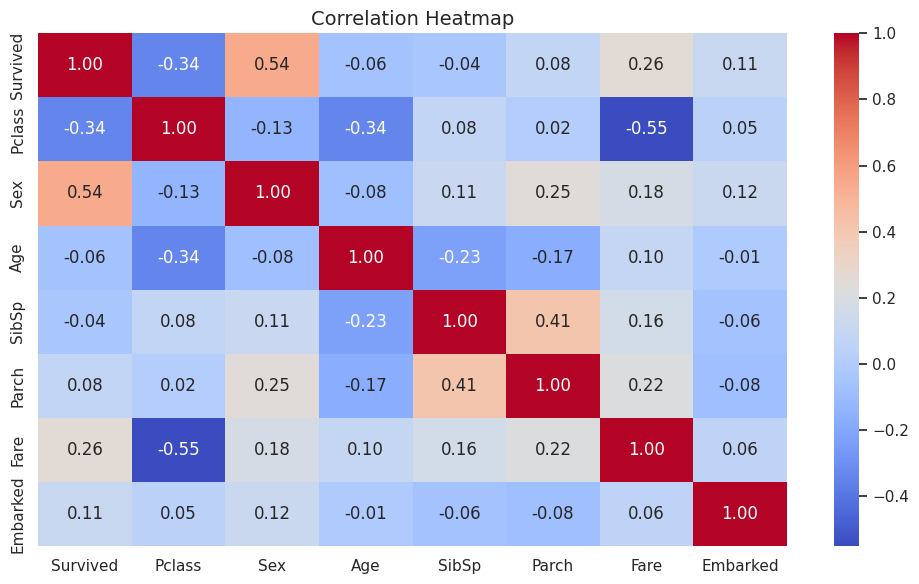

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap",fontsize=14)
plt.tight_layout()
plt.show()



In [16]:
print("Correlation with Survival:")
print(df.corr()['Survived'].sort_values(ascending=False))

Correlation with Survival:
Survived    1.000000
Sex         0.543351
Fare        0.257307
Embarked    0.106811
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Pclass     -0.338481
Name: Survived, dtype: float64


In [17]:
df.drop(columns=['SibSp','Parch'],inplace=True)

In [18]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
print("Training set size:",X_train.shape)
print("Testing set size:",X_test.shape)

Training set size: (712, 5)
Testing set size: (179, 5)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr.pred=lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
rf.pred=lr.predict(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred=knn.predict(X_test)

print("All models trained successfully")

All models trained successfully


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
results={
    'Model':['Logistic Regression','Random Forest','KNN'],
    'Accuracy':[accuracy_score(y_test,lr.pred),
                accuracy_score(y_test,rf.pred),
                accuracy_score(y_test,knn_pred)
               ],
             'Precision':[precision_score(y_test,lr.pred),
                          precision_score(y_test,rf.pred),
                          precision_score(y_test,knn_pred)
                         ],
             'Recall':[recall_score(y_test,lr.pred),
                       recall_score(y_test,rf.pred),
                       recall_score(y_test,knn_pred)
                      ],
             'F1 Score':[f1_score(y_test,lr.pred),
                        f1_score(y_test,rf.pred),
                        f1_score(y_test,knn_pred)
                       ]

}

results_df=pd.DataFrame(results)
results_df=results_df.round(4)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.7933     0.7606  0.7297    0.7448
      Random Forest    0.7933     0.7606  0.7297    0.7448
                KNN    0.6983     0.6852  0.5000    0.5781


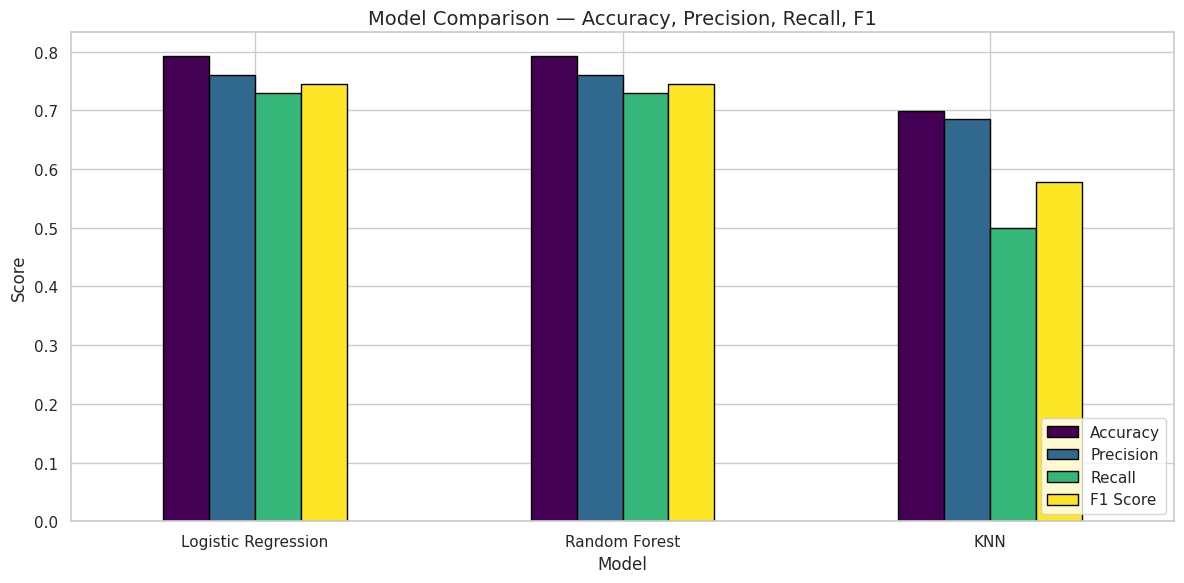

In [24]:

results_df.set_index('Model').plot(kind='bar', figsize=(12, 6),
                                    colormap='viridis', edgecolor='black')
plt.title("Model Comparison — Accuracy, Precision, Recall, F1", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

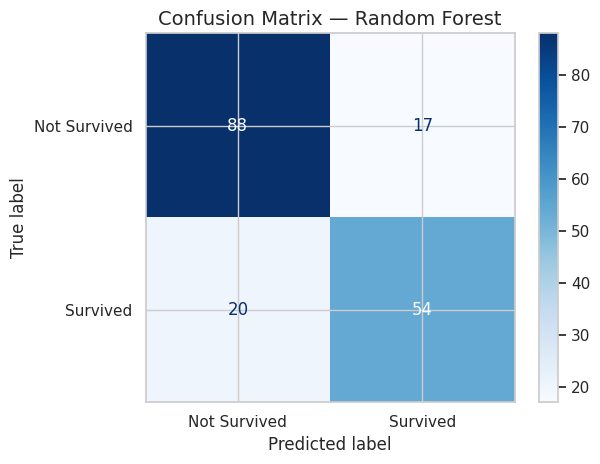

Classification Report - Random Forest:
              precision    recall  f1-score   support

Not Survived       0.81      0.84      0.83       105
    Survived       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179



In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf.pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Random Forest", fontsize=14)
plt.tight_layout()
plt.show()

print("Classification Report - Random Forest:")
print(classification_report(y_test, rf.pred,target_names=['Not Survived','Survived']))

Best Model Analysis and Conclusion

1. Starting with Random forest and the logistic
regression both recieved the highest accuracy,which is 79.33% and outperformed KNN.

2. Randomforest is selected as best model because it takescare of nonlinear stat better.
It also more strong at overfitting than L.R.

3. The confusion matrix shows Random Forest correctly identified most survivors and non-survivors, with less false predictions

4. KNN performed less accurate with a Recall of 0.50 which meant missed half the actual survivors.

5. The strongest Preedictors of survival were the Gender and Passeneger Class columns.
confirming that women and higher-class passengers had better survival rate.









